# Financial QA Evaluation Pipeline
**PwC Assignment** - Pipeline Design and Evaluation

This notebook runs an end-to-end LLM-based question-answering evaluation over 50 samples from the Financial QA 10-K dataset.
Three models via OpenRouter are compared:
- **Model A**: `google/gemini-3.1-flash-lite-preview`
- **Model B**: `openai/gpt-5.4-mini`
- **Model C**: `mistralai/mistral-large-2512`

Additionally, for the LLM-as-a-Judge metric, a more powerful model is used: `google/gemini-3-flash-preview`.

All code is structured to be reproducible. Results are saved to `outputs/`. To run the notebook and get results, ensure you have the OpenRouter API key set in your .env file as "API_Key".

## 1. Setup
Install dependencies and load environment variables.

In [ ]:
# Install dependencies if needed
# % pip install openai scikit-learn python-dotenv matplotlib

In [1]:
import os
import json
import csv
import matplotlib.pyplot as plt
import matplotlib
from dotenv import load_dotenv
load_dotenv()

# Verify API key
assert os.environ.get('API_KEY'), "API_KEY environment variable not set!"
print("API_KEY found.")

API_KEY found.


## 2. Load Dataset
We use exactly 50 samples as required, taken from the first 50 rows of the CSV.

In [2]:
# Load our pipeline.py and config.py logic
import pipeline as pm
import config as cfg

samples = pm.load_samples()
print(f"Loaded {len(samples)} samples")

# Preview few samples
for s in samples[:3]:
    print(f"\n[{s['id']}] Ticker: {s['ticker']}  |  Filing: {s['filing']}")
    print(f"Q: {s['question'][:100]}...")
    print(f"A: {s['reference_answer'][:80]}...")
    print(f"Context length: {len(s['context'])} chars")

Loaded 50 samples

[1] Ticker: NVDA  |  Filing: 2023_10K
Q: What area did NVIDIA initially focus on before expanding to other computationally intensive fields?...
A: NVIDIA initially focused on PC graphics....
Context length: 128 chars

[2] Ticker: NVDA  |  Filing: 2023_10K
Q: What are some of the recent applications of GPU-powered deep learning as mentioned by NVIDIA?...
A: Recent applications of GPU-powered deep learning include recommendation systems,...
Context length: 601 chars

[3] Ticker: NVDA  |  Filing: 2023_10K
Q: What significant invention did NVIDIA create in 1999?...
A: NVIDIA invented the GPU in 1999....
Context length: 124 chars


## 3. System Prompt Design
The prompt enforces three key properties:
1. **Context-grounding** - the model is explicitly told not to use external knowledge
2. **Structured output** - JSON schema enforced for reliable parsing
3. **Abstention** - first-class option when context is insufficient

In [3]:
print("SYSTEM PROMPT: ")
print(cfg.SYSTEM_PROMPT)

print("\nEXAMPLE USER MESSAGE (sample 1): ")
print(f"CONTEXT:\n{samples[0]['context'][:300]}...\n\nQUESTION:\n{samples[0]['question']}\n\nRespond with strict JSON.")

SYSTEM PROMPT: 

You are a highly precise financial extraction assistant.
Your task is to answer questions strictly based on the context provided.

RULES:
1. Use ONLY information explicitly stated in the context. Do NOT use external knowledge.
2. If the context does not contain sufficient information to answer, set "abstain" to true.
3. Keep your answer concise (1-3 sentences maximum). Extract phrasing strictly from the text when possible.
4. Return ONLY a valid JSON object.

RESPONSE FORMAT:
{
  "answer": "<concise answer, or empty string if abstaining>",
  "confidence": <float 0.0 to 1.0 reflecting support quality>,
  "abstain": <true if context is insufficient, false otherwise>,
  "reason": "<reason for abstaining, or empty>"
}


EXAMPLE USER MESSAGE (sample 1): 
CONTEXT:
Since our original focus on PC graphics, we have expanded to several other large and important computationally intensive fields....

QUESTION:
What area did NVIDIA initially focus on before expanding to other compu

## 4. Run Pipeline
Model A (Gemini)

In [4]:
predictions_a = await pm.run_inference(
    model_name=cfg.MODEL_A_NAME,
    model_label=cfg.MODEL_A_LABEL,
    samples=samples,
)


--- Running Async Inference: gemini-3.1-flash-lite (google/gemini-3.1-flash-lite-preview) ---
  [8/50] NVDA | OK
  [2/50] NVDA | OK
  [34/50] NVDA | OK
  [45/50] NVDA | OK
  [1/50] NVDA | OK
  [24/50] NVDA | OK
  [29/50] NVDA | OK
  [18/50] NVDA | OK
  [13/50] NVDA | OK
  [15/50] NVDA | OK
  [38/50] NVDA | OK
  [37/50] NVDA | OK
  [7/50] NVDA | OK
  [50/50] NVDA | OK
  [14/50] NVDA | OK
  [26/50] NVDA | OK
  [32/50] NVDA | OK
  [44/50] NVDA | OK
  [4/50] NVDA | OK
  [46/50] NVDA | OK
  [12/50] NVDA | OK
  [27/50] NVDA | OK
  [31/50] NVDA | OK
  [47/50] NVDA | OK
  [48/50] NVDA | OK
  [40/50] NVDA | OK
  [49/50] NVDA | OK
  [23/50] NVDA | OK
  [33/50] NVDA | OK
  [43/50] NVDA | OK
  [25/50] NVDA | OK
  [11/50] NVDA | OK
  [20/50] NVDA | OK
  [39/50] NVDA | OK
  [36/50] NVDA | OK
  [6/50] NVDA | OK
  [3/50] NVDA | OK
  [5/50] NVDA | OK
  [41/50] NVDA | OK
  [35/50] NVDA | OK
  [30/50] NVDA | OK
  [28/50] NVDA | ABSTAIN
  [17/50] NVDA | OK
  [19/50] NVDA | OK
  [9/50] NVDA | OK
  [21/50]

In [5]:
results_a, summary_a = await pm.evaluate(predictions_a)

Running LLM-as-a-Judge for 50 predictions...
  [judge 5/50] MATCH
  [judge 21/50] NO MATCH
  [judge 6/50] MATCH
  [judge 44/50] MATCH
  [judge 49/50] MATCH
  [judge 19/50] MATCH
  [judge 50/50] MATCH
  [judge 26/50] MATCH
  [judge 16/50] MATCH
  [judge 22/50] MATCH
  [judge 43/50] MATCH
  [judge 40/50] MATCH
  [judge 4/50] MATCH
  [judge 11/50] MATCH
  [judge 14/50] MATCH
  [judge 2/50] MATCH
  [judge 17/50] MATCH
  [judge 8/50] MATCH
  [judge 32/50] MATCH
  [judge 7/50] MATCH
  [judge 39/50] MATCH
  [judge 29/50] MATCH
  [judge 15/50] MATCH
  [judge 1/50] MATCH
  [judge 18/50] MATCH
  [judge 25/50] MATCH
  [judge 20/50] MATCH
  [judge 47/50] NO MATCH
  [judge 27/50] MATCH
  [judge 36/50] MATCH
  [judge 9/50] MATCH
  [judge 30/50] MATCH
  [judge 45/50] MATCH
  [judge 42/50] MATCH
  [judge 33/50] MATCH
  [judge 37/50] MATCH
  [judge 41/50] MATCH
  [judge 23/50] MATCH
  [judge 3/50] MATCH
  [judge 13/50] MATCH
  [judge 24/50] MATCH
  [judge 10/50] MATCH
  [judge 34/50] MATCH
  [judge 38/

Model B (GPT)

In [6]:
predictions_b = await pm.run_inference(
    model_name=cfg.MODEL_B_NAME,
    model_label=cfg.MODEL_B_LABEL,
    samples=samples,
)


--- Running Async Inference: gpt-5.4-mini (openai/gpt-5.4-mini) ---
  [18/50] NVDA | OK
  [43/50] NVDA | OK
  [45/50] NVDA | OK
  [8/50] NVDA | OK
  [47/50] NVDA | OK
  [38/50] NVDA | OK
  [16/50] NVDA | OK
  [3/50] NVDA | OK
  [7/50] NVDA | OK
  [11/50] NVDA | OK
  [41/50] NVDA | OK
  [39/50] NVDA | OK
  [29/50] NVDA | OK
  [37/50] NVDA | OK
  [2/50] NVDA | OK
  [42/50] NVDA | OK
  [19/50] NVDA | OK
  [48/50] NVDA | OK
  [9/50] NVDA | OK
  [26/50] NVDA | OK
  [1/50] NVDA | OK
  [36/50] NVDA | OK
  [46/50] NVDA | OK
  [6/50] NVDA | OK
  [44/50] NVDA | OK
  [21/50] NVDA | OK
  [50/50] NVDA | OK
  [31/50] NVDA | OK
  [34/50] NVDA | OK
  [12/50] NVDA | OK
  [10/50] NVDA | OK
  [17/50] NVDA | OK
  [49/50] NVDA | OK
  [28/50] NVDA | OK
  [30/50] NVDA | OK
  [23/50] NVDA | OK
  [27/50] NVDA | OK
  [35/50] NVDA | OK
  [33/50] NVDA | OK
  [22/50] NVDA | OK
  [13/50] NVDA | OK
  [24/50] NVDA | OK
  [15/50] NVDA | OK
  [5/50] NVDA | OK
  [40/50] NVDA | OK
  [20/50] NVDA | OK
  [32/50] NVDA | OK

In [7]:
results_b, summary_b = await pm.evaluate(predictions_b)

Running LLM-as-a-Judge for 50 predictions...
  [judge 6/50] MATCH
  [judge 7/50] MATCH
  [judge 2/50] MATCH
  [judge 4/50] MATCH
  [judge 14/50] MATCH
  [judge 46/50] MATCH
  [judge 21/50] MATCH
  [judge 36/50] MATCH
  [judge 16/50] MATCH
  [judge 5/50] MATCH
  [judge 18/50] MATCH
  [judge 27/50] MATCH
  [judge 17/50] MATCH
  [judge 29/50] MATCH
  [judge 8/50] MATCH
  [judge 50/50] MATCH
  [judge 33/50] MATCH
  [judge 31/50] MATCH
  [judge 26/50] MATCH
  [judge 35/50] MATCH
  [judge 28/50] MATCH
  [judge 37/50] MATCH
  [judge 10/50] MATCH
  [judge 15/50] MATCH
  [judge 48/50] MATCH
  [judge 22/50] MATCH
  [judge 40/50] MATCH
  [judge 41/50] MATCH
  [judge 19/50] MATCH
  [judge 20/50] MATCH
  [judge 44/50] MATCH
  [judge 38/50] MATCH
  [judge 43/50] MATCH
  [judge 30/50] MATCH
  [judge 49/50] MATCH
  [judge 13/50] MATCH
  [judge 1/50] MATCH
  [judge 9/50] MATCH
  [judge 12/50] MATCH
  [judge 23/50] MATCH
  [judge 24/50] MATCH
  [judge 32/50] MATCH
  [judge 39/50] MATCH
  [judge 34/50] M

Model C (Mistral)

In [8]:
predictions_c = await pm.run_inference(
    model_name=cfg.MODEL_C_NAME,
    model_label=cfg.MODEL_C_LABEL,
    samples=samples,
)


--- Running Async Inference: mistral-large-2512 (mistralai/mistral-large-2512) ---
  [1/50] NVDA | OK
  [8/50] NVDA | OK
  [49/50] NVDA | OK
  [45/50] NVDA | OK
  [3/50] NVDA | OK
  [42/50] NVDA | OK
  [5/50] NVDA | OK
  [26/50] NVDA | OK
  [30/50] NVDA | OK
  [29/50] NVDA | OK
  [2/50] NVDA | OK
  [18/50] NVDA | OK
  [46/50] NVDA | OK
  [11/50] NVDA | OK
  [41/50] NVDA | OK
  [48/50] NVDA | OK
  [16/50] NVDA | OK
  [17/50] NVDA | OK
  [50/50] NVDA | OK
  [34/50] NVDA | OK
  [37/50] NVDA | OK
  [14/50] NVDA | OK
  [4/50] NVDA | OK
  [15/50] NVDA | OK
  [40/50] NVDA | OK
  [12/50] NVDA | OK
  [9/50] NVDA | OK
  [43/50] NVDA | OK
  [22/50] NVDA | OK
  [38/50] NVDA | OK
  [10/50] NVDA | OK
  [24/50] NVDA | OK
  [7/50] NVDA | OK
  [13/50] NVDA | OK
  [39/50] NVDA | OK
  [20/50] NVDA | OK
  [44/50] NVDA | OK
  [35/50] NVDA | OK
  [27/50] NVDA | OK
  [32/50] NVDA | OK
  [36/50] NVDA | OK
  [6/50] NVDA | OK
  [23/50] NVDA | OK
  [25/50] NVDA | OK
  [19/50] NVDA | OK
  [28/50] NVDA | ABSTAIN


In [9]:
results_c, summary_c = await pm.evaluate(predictions_c)

Running LLM-as-a-Judge for 50 predictions...
  [judge 20/50] MATCH
  [judge 15/50] MATCH
  [judge 9/50] MATCH
  [judge 30/50] MATCH
  [judge 23/50] MATCH
  [judge 21/50] MATCH
  [judge 32/50] MATCH
  [judge 14/50] MATCH
  [judge 47/50] MATCH
  [judge 39/50] MATCH
  [judge 2/50] MATCH
  [judge 35/50] MATCH
  [judge 41/50] MATCH
  [judge 48/50] MATCH
  [judge 17/50] MATCH
  [judge 1/50] MATCH
  [judge 50/50] MATCH
  [judge 36/50] MATCH
  [judge 49/50] MATCH
  [judge 38/50] MATCH
  [judge 19/50] MATCH
  [judge 12/50] MATCH
  [judge 24/50] MATCH
  [judge 29/50] MATCH
  [judge 4/50] MATCH
  [judge 7/50] MATCH
  [judge 34/50] NO MATCH
  [judge 6/50] MATCH
  [judge 18/50] MATCH
  [judge 5/50] MATCH
  [judge 13/50] MATCH
  [judge 16/50] MATCH
  [judge 22/50] MATCH
  [judge 11/50] MATCH
  [judge 8/50] MATCH
  [judge 37/50] MATCH
  [judge 10/50] MATCH
  [judge 44/50] MATCH
  [judge 33/50] MATCH
  [judge 40/50] MATCH
  [judge 43/50] MATCH
  [judge 27/50] MATCH
  [judge 3/50] MATCH
  [judge 45/50]

## 5. Evaluation
Metrics computed:
- **LLM as a Judge**: Factual equivalence verified by Gemini 3 Flash.
- **Cosine Similarity**: Vector-based semantic overlap.
- **Mean Confidence**: Model's internal certainty score.
- **Abstention Rate**: coverage vs reliability trade-off.

In [10]:
# Comparison metrics
cfg.compare_metrics(summary_a, summary_b, summary_c)

# Save outputs
cfg.save_outputs(predictions_a, predictions_b, predictions_c, summary_a, summary_b, summary_c)


Metric               | gemini-3.1-flash-lite | gpt-5.4-mini         | mistral-large-2512  
llm_as_a_judge       | 0.9400               | 1.0000               | 0.9400              
cosine_sim           | 0.7697               | 0.6833               | 0.7358              
mean_confidence      | 1.0000               | 0.9830               | 0.9800              
abstention_rate      | 0.0200               | 0.0000               | 0.0200              

Outputs saved to outputs/


## 6. Visualisations

Metrics comparison.

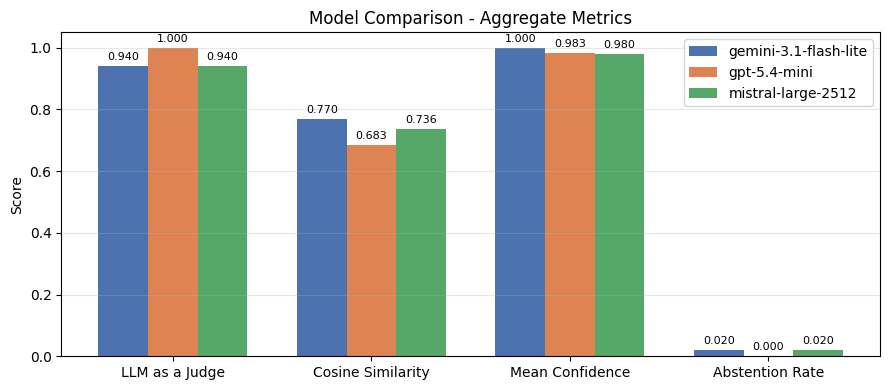

Chart saved: outputs/chart_metric_comparison.png


In [11]:
metrics = ['llm_as_a_judge', 'cosine_sim', 'mean_confidence', 'abstention_rate']
labels  = ['LLM as a Judge', 'Cosine Similarity', 'Mean Confidence', 'Abstention Rate']

vals_a = [summary_a[m] for m in metrics]
vals_b = [summary_b[m] for m in metrics]
vals_c = [summary_c[m] for m in metrics]

x = range(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 4))
bars_a = ax.bar([i - width for i in x], vals_a, width, label=cfg.MODEL_A_LABEL, color='#4C72B0')
bars_b = ax.bar([i for i in x], vals_b, width, label=cfg.MODEL_B_LABEL, color='#DD8452')
bars_c = ax.bar([i + width for i in x], vals_c, width, label=cfg.MODEL_C_LABEL, color='#55A868')

ax.set_ylabel('Score')
ax.set_title('Model Comparison - Aggregate Metrics')
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.05)
ax.legend()
ax.bar_label(bars_a, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars_b, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(bars_c, fmt='%.3f', padding=3, fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/chart_metric_comparison.png', bbox_inches='tight')
plt.show()
print("Chart saved: outputs/chart_metric_comparison.png")

Confidence distribution.

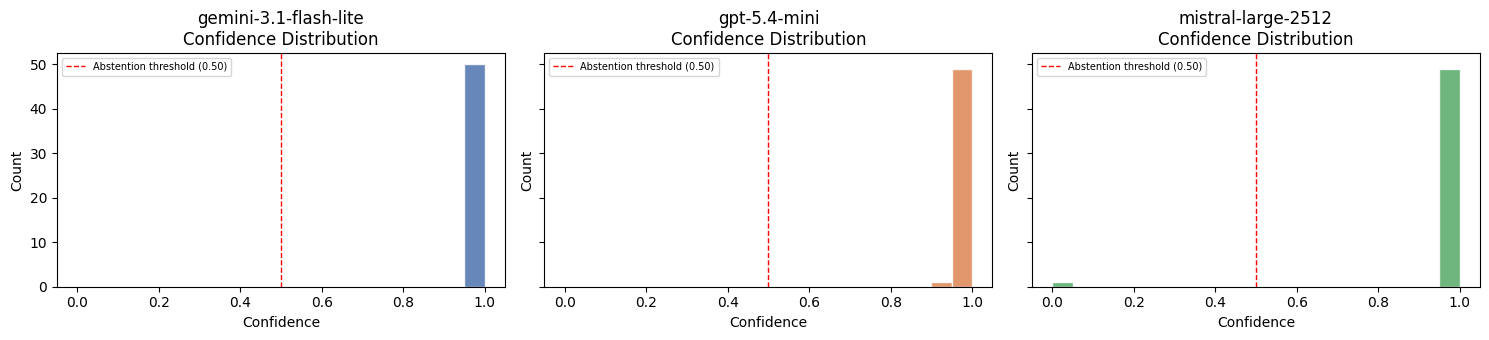

Chart saved: outputs/chart_confidence_distribution.png


In [12]:
conf_a = [p['confidence'] for p in predictions_a]
conf_b = [p['confidence'] for p in predictions_b]
conf_c = [p['confidence'] for p in predictions_c]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)
for ax, conf, label, color in zip(
    axes,
    [conf_a, conf_b, conf_c],
    [cfg.MODEL_A_LABEL, cfg.MODEL_B_LABEL, cfg.MODEL_C_LABEL],
    ['#4C72B0', '#DD8452', '#55A868'],
):
    ax.hist(conf, bins=20, range=(0, 1), color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'{label}\nConfidence Distribution')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Count')
    ax.axvline(0.50, color='red', linestyle='--', linewidth=1, label='Abstention threshold (0.50)')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('outputs/chart_confidence_distribution.png', bbox_inches='tight')
plt.show()
print("Chart saved: outputs/chart_confidence_distribution.png")

## 7. Error Analysis
Examine cases where Model A was wrong (Cosine Sim < 0.5 or LLM as a Judge == 0, not abstained) to surface failure patterns.

In [13]:
failures_a = [
    r for r in results_a
    if (r.get('cosine_sim', 0) < 0.5 or r.get('llm_as_a_judge', 1) == 0) and not r['abstain']
]

print(f"Model A - low score answered predictions: {len(failures_a)}/{len(results_a)}")

# Show 3 worst Cosine Similarity examples
worst = sorted(failures_a, key=lambda r: r['cosine_sim'])[:3]
for i, r in enumerate(worst, 1):
    print(f"\nFailure {i} (id={r['id']}, ticker={r['ticker']})")
    print(f"Q: {r['question'][:120]}")
    print(f"Ref: {r['reference_answer'][:120]}")
    print(f"Pred:{r['answer'][:120]}")
    print(f"CosineSim: {r['cosine_sim']:.3f}  Conf: {r['confidence']:.2f}")

Model A - low score answered predictions: 5/50

Failure 1 (id=47, ticker=NVDA)
Q: What is the percentage of Black or African American and Hispanic or Latino employees in the workforce in the United Stat
Ref: 6%
Pred:6% of the workforce in the United States is composed of Black or African American and Hispanic or Latino employees.
CosineSim: 0.196  Conf: 1.00

Failure 2 (id=45, ticker=NVDA)
Q: What percentage of the global workforce was female at the end of fiscal year 2023?
Ref: 19%
Pred:At the end of fiscal year 2023, 19% of the global workforce was female.
CosineSim: 0.236  Conf: 1.00

Failure 3 (id=6, ticker=NVDA)
Q: What industries use NVIDIA's GPUs and software for automation?
Ref: NVIDIA's GPUs and software are used for automation in various industries including transportation, healthcare, financial
Pred:The transportation, healthcare, and financial services industries use these platforms for automation.
CosineSim: 0.404  Conf: 1.00


Examine cases where Model B was wrong (Cosine Sim < 0.5 or LLM as a Judge == 0, not abstained) to surface failure patterns.

In [14]:
failures_b = [
    r for r in results_b
    if (r.get('cosine_sim', 0) < 0.5 or r.get('llm_as_a_judge', 1) == 0) and not r['abstain']
]

print(f"Model B - low score answered predictions: {len(failures_b)}/{len(results_b)}")

# Show 3 worst Cosine Similarity examples
worst = sorted(failures_b, key=lambda r: r['cosine_sim'])[:3]
for i, r in enumerate(worst, 1):
    print(f"\nFailure {i} (id={r['id']}, ticker={r['ticker']})")
    print(f"Q: {r['question'][:120]}")
    print(f"Ref: {r['reference_answer'][:120]}")
    print(f"Pred:{r['answer'][:120]}")
    print(f"CosineSim: {r['cosine_sim']:.3f}  Conf: {r['confidence']:.2f}")

Model B - low score answered predictions: 8/50

Failure 1 (id=43, ticker=NVDA)
Q: What was the overall turnover rate at the company in fiscal year 2023?
Ref: The overall turnover rate at the company in fiscal year 2023 was 5.3%.
Pred:5.3%
CosineSim: 0.000  Conf: 0.99

Failure 2 (id=38, ticker=NVDA)
Q: What percentage of global electricity usage does NVIDIA aim to match with renewable energy by the end of fiscal year 202
Ref: By the end of fiscal year 2025, NVIDIA aims to match 100% of its global electricity usage with renewable energy.
Pred:100%
CosineSim: 0.213  Conf: 0.99

Failure 3 (id=1, ticker=NVDA)
Q: What area did NVIDIA initially focus on before expanding to other computationally intensive fields?
Ref: NVIDIA initially focused on PC graphics.
Pred:PC graphics
CosineSim: 0.289  Conf: 0.99


Examine cases where Model C was wrong (Cosine Sim < 0.5 or LLM as a Judge == 0, not abstained) to surface failure patterns.

In [15]:
failures_c = [
    r for r in results_c
    if (r.get('cosine_sim', 0) < 0.5 or r.get('llm_as_a_judge', 1) == 0) and not r['abstain']
]

print(f"Model C - low score answered predictions: {len(failures_c)}/{len(results_c)}")

# Show 3 worst Cosine Similarity examples
worst = sorted(failures_c, key=lambda r: r['cosine_sim'])[:3]
for i, r in enumerate(worst, 1):
    print(f"\nFailure {i} (id={r['id']}, ticker={r['ticker']})")
    print(f"Q: {r['question'][:120]}")
    print(f"Ref: {r['reference_answer'][:120]}")
    print(f"Pred:{r['answer'][:120]}")
    print(f"CosineSim: {r['cosine_sim']:.3f}  Conf: {r['confidence']:.2f}")

Model C - low score answered predictions: 9/50

Failure 1 (id=47, ticker=NVDA)
Q: What is the percentage of Black or African American and Hispanic or Latino employees in the workforce in the United Stat
Ref: 6%
Pred:6% of our workforce in the United States [is] composed of Black or African American and Hispanic or Latino employees
CosineSim: 0.204  Conf: 1.00

Failure 2 (id=45, ticker=NVDA)
Q: What percentage of the global workforce was female at the end of fiscal year 2023?
Ref: 19%
Pred:19% of the global workforce was female at the end of fiscal year 2023.
CosineSim: 0.236  Conf: 1.00

Failure 3 (id=1, ticker=NVDA)
Q: What area did NVIDIA initially focus on before expanding to other computationally intensive fields?
Ref: NVIDIA initially focused on PC graphics.
Pred:PC graphics
CosineSim: 0.289  Conf: 1.00


## 8. Summary & Recommendation

Based on the evaluation results, document your recommendation here.
Replace the placeholders below once you have run the cells above.

In [16]:
print("FINAL SUMMARY: ")

for summary, label in [(summary_a, cfg.MODEL_A_LABEL), (summary_b, cfg.MODEL_B_LABEL), (summary_c, cfg.MODEL_C_LABEL)]:
    print(f"\n{label}:")
    print(f"LLM as a Judge: {summary['llm_as_a_judge']:.4f}")
    print(f"Cosine Similarity: {summary['cosine_sim']:.4f}")

    print(f"Mean Confidence: {summary['mean_confidence']:.2f}")
    print(f"Abstention: {summary['abstention_rate']:.1%} ({summary['n_abstained']}/{summary['n_samples']})")

def get_score(summary):
    return summary['llm_as_a_judge'] + summary['cosine_sim'] + summary['mean_confidence'] - summary['abstention_rate']

scores = [(get_score(summary_a), cfg.MODEL_A_LABEL), (get_score(summary_b), cfg.MODEL_B_LABEL), (get_score(summary_c), cfg.MODEL_C_LABEL)]
winner = max(scores, key=lambda x: x[0])[1]
print(f"\nRecommended model: {winner}")

FINAL SUMMARY: 

gemini-3.1-flash-lite:
LLM as a Judge: 0.9400
Cosine Similarity: 0.7697
Mean Confidence: 1.00
Abstention: 2.0% (1/50)

gpt-5.4-mini:
LLM as a Judge: 1.0000
Cosine Similarity: 0.6833
Mean Confidence: 0.98
Abstention: 0.0% (0/50)

mistral-large-2512:
LLM as a Judge: 0.9400
Cosine Similarity: 0.7358
Mean Confidence: 0.98
Abstention: 2.0% (1/50)

Recommended model: gemini-3.1-flash-lite
